In [6]:
# to load and manipulate data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# to split the data into train and test sets
from sklearn.model_selection import train_test_split

# to build a linear regression model
from sklearn.linear_model import LinearRegression

# to check a regression model's performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Loading the dataset

In [5]:
sales = pd.read_csv(r"C:\Users\New\Desktop\Jupyter Notebook\Data Science Project\Sales (1).csv")

In [7]:
# creating a copy of the data
data = sales.copy()

## Data Overview

In [9]:
data.head(5)

,Advertising Expenditure,Campaign Engagement Score,Discount Percentage,Average Customer Rating,Product Price,Return Rate,Length of Product Description,Region,Popularity,Sales
0,644.049317,54.565531,25.267151,4.604634,1599.575723,2.133580,231.185389,East,High,26246.91291
1,521.483294,46.875226,35.075859,4.358693,1586.464404,1.553437,262.686931,West,Very High,21432.16935
2,540.079510,42.287145,12.618381,4.571018,1301.644856,2.274891,324.347319,South,Very High,22551.92436
3,627.938419,61.825441,31.588445,4.234209,1601.041884,1.035971,447.710984,South,Very High,27792.29446
4,471.149948,31.061512,9.198991,4.816215,1496.734345,3.276840,310.055333,East,Moderate,17354.77148


In [10]:
data.shape

(3000, 10)

* The dataset has 3000 rows and 10 columns.

In [11]:
#checking the attributes of the dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Advertising Expenditure        3000 non-null   float64
 1   Campaign Engagement Score      3000 non-null   float64
 2   Discount Percentage            3000 non-null   float64
 3   Average Customer Rating        3000 non-null   float64
 4   Product Price                  3000 non-null   float64
 5   Return Rate                    3000 non-null   float64
 6   Length of Product Description  3000 non-null   float64
 7   Region                         3000 non-null   str    
 8   Popularity                     3000 non-null   str    
 9   Sales                          3000 non-null   float64
dtypes: float64(8), str(2)
memory usage: 234.5 KB


* There are 8 numerical and 2 categorical variables in the data.

In [13]:
# checking the statistical summary of the dataset
data.describe()

,Advertising Expenditure,Campaign Engagement Score,Discount Percentage,Average Customer Rating,Product Price,Return Rate,Length of Product Description,Sales
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,607.727150,49.456305,28.997927,4.408783,1434.718134,1.666106,248.696636,23858.638609
std,82.025112,13.171290,4.700923,0.227823,222.832467,0.900435,60.800024,3611.748810
min,97.250000,0.000000,0.000000,3.649450,9.780000,0.033720,42.000000,3257.595426
25%,561.984787,40.697530,26.222998,4.251118,1306.155958,0.954551,207.076217,21632.968838
50%,616.116596,49.478699,29.552853,4.432254,1461.301831,1.537856,249.348398,24087.129995
75%,666.331853,58.150891,32.259294,4.583205,1587.671790,2.285394,288.875650,26421.772433
max,801.500000,98.750000,40.540000,4.874450,2000.560000,4.534866,496.000000,34421.427430


* On an average, the retailer has sold mobiles and tablets worth ~$24k.
* On an average, ~600 dollars have been spent on adversiting.
* The mobiles and tablets sold by the retailer are priced between 10 to 2000 dollars approx.

In [14]:
#checking for missing values
data.isnull().sum()


Advertising Expenditure          0
Campaign Engagement Score        0
Discount Percentage              0
Average Customer Rating          0
Product Price                    0
Return Rate                      0
Length of Product Description    0
Region                           0
Popularity                       0
Sales                            0
dtype: int64

* There are no missing values in the dataset

In [15]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

* There are no duplicate value in the dataset

## Exploratory Data Analysis

**Univariate Analysis**

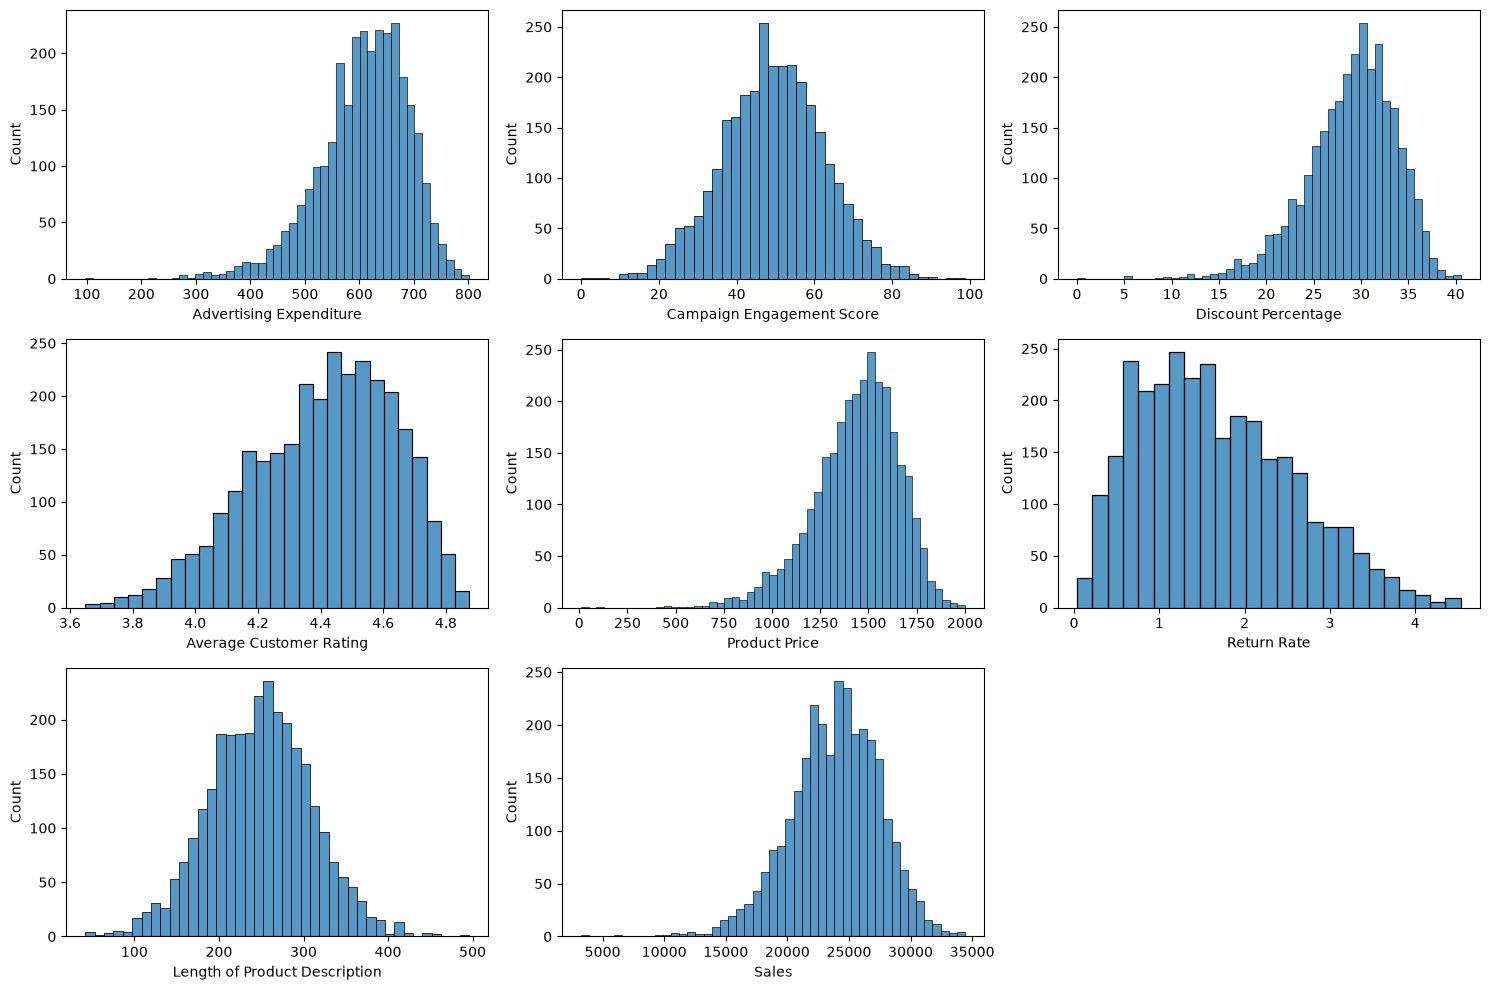

In [16]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
features = data.select_dtypes(include=['number']).columns.tolist()

# creating the histograms
for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)    # plot the histogram

plt.tight_layout()    # to add spacing between plots
plt.show()

* Sales, Advertising Expenditure, Discount Percentage, and Product Price exhibit left-skewed distributions.
* Return Rate exhibits a right-skewed distribution.
* Campaign Engagement Score and Length of Product Description are approx. normally distributed.

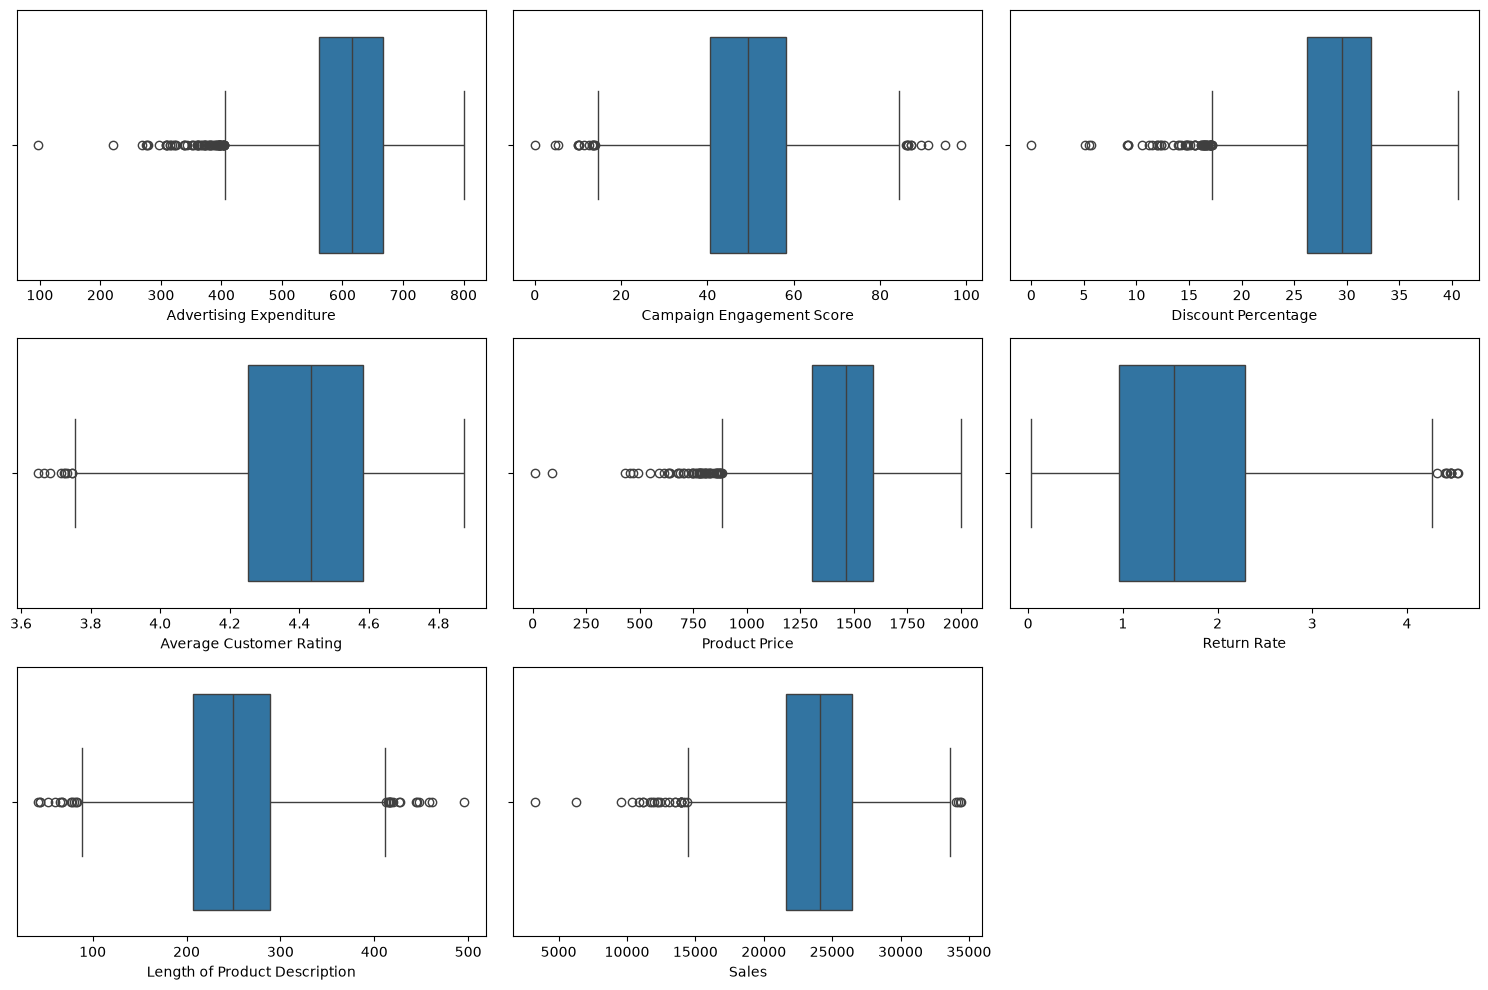

In [17]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
features = data.select_dtypes(include=['number']).columns.tolist()

# creating the histograms
for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(data=data, x=feature)    # plot the histogram

plt.tight_layout()    # to add spacing between plots
plt.show()

* There are outliers in all the attributes in the data.

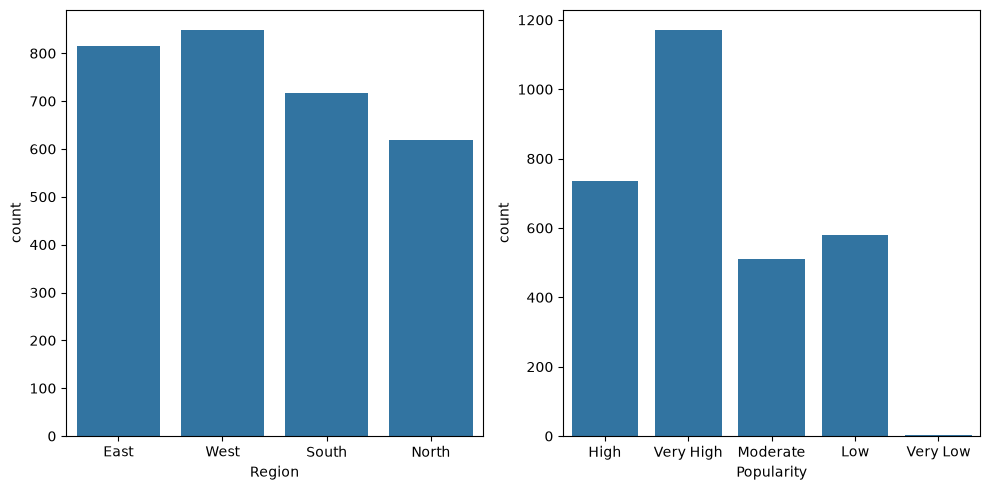

In [18]:
# defining the figure size
plt.figure(figsize=(10, 5))

# defining the list of categorical features to plot
features = data.select_dtypes(exclude=['number']).columns.tolist()

# creating the histograms
for i, feature in enumerate(features):
    plt.subplot(1, 2, i+1)    # assign a subplot in the main plot
    sns.countplot(data=data, x=feature)    # plot the histogram

plt.tight_layout()    # to add spacing between plots
plt.show()

* The North region has slightly fewer data points than the others.
* Most of the mobiles and tablets sold are very popular, and only a negligible amount of them are very unpopular.

**Bivariate Analysis**

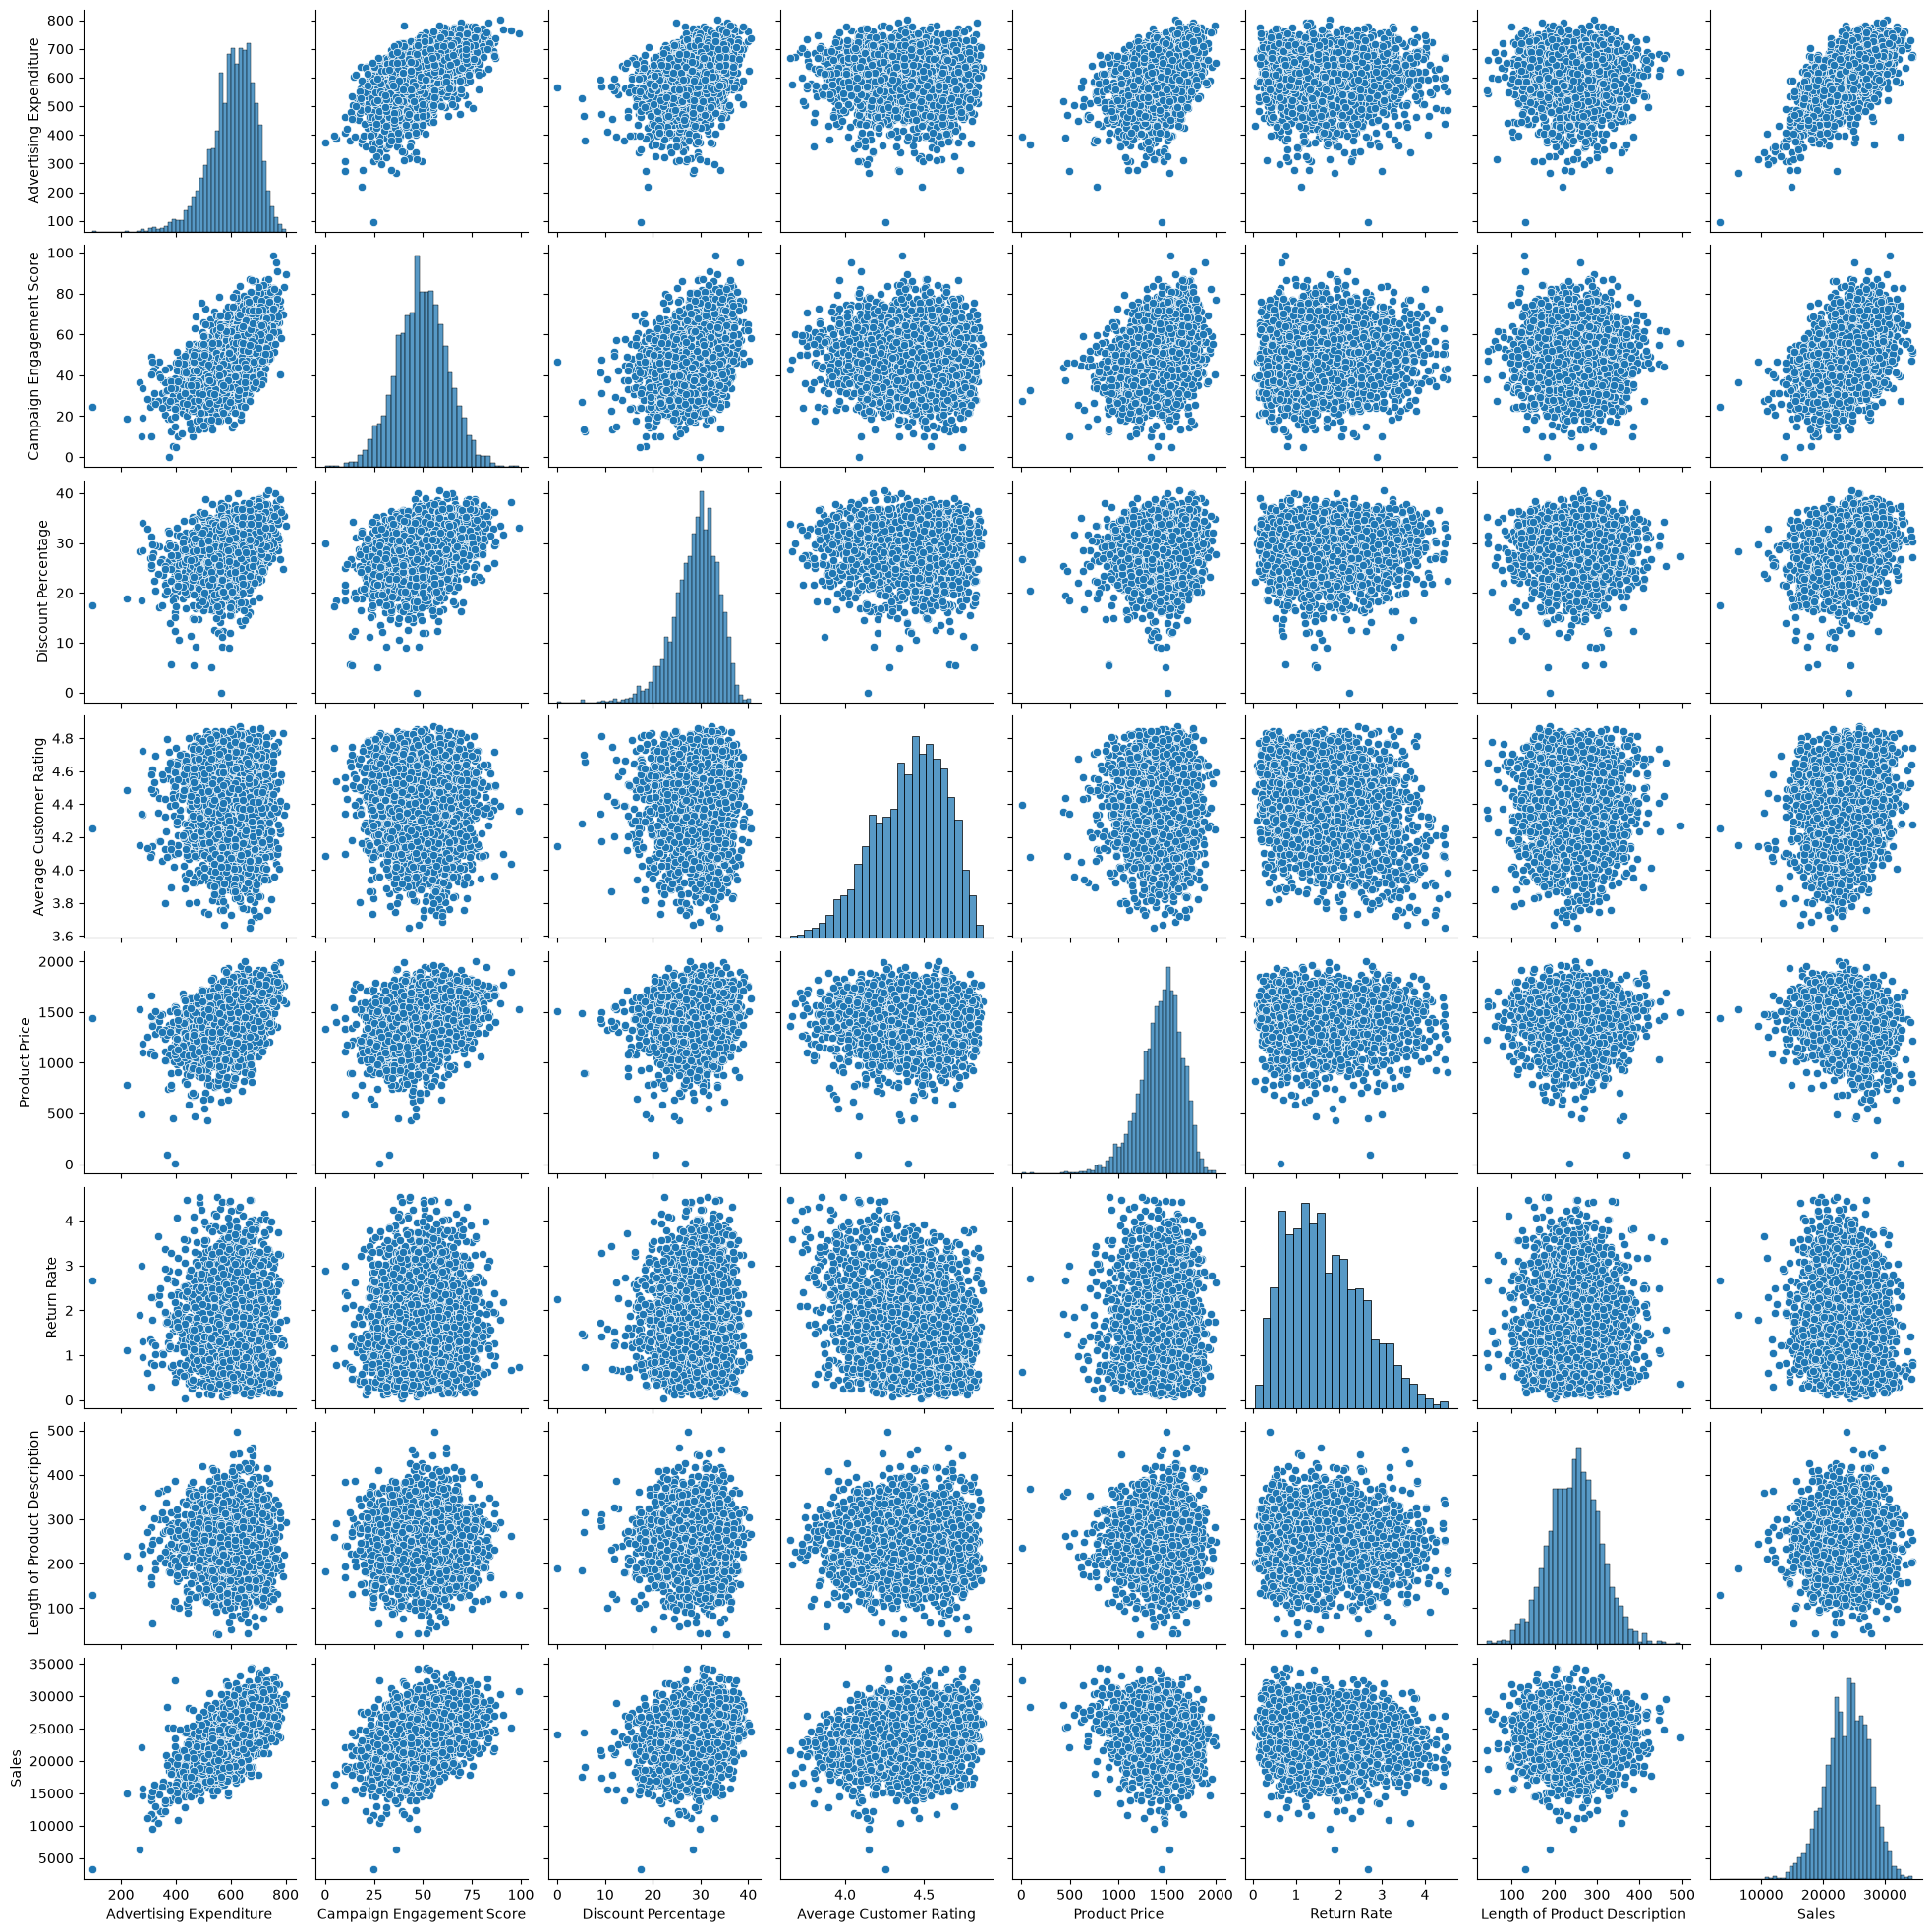

In [19]:
sns.pairplot(data);

- Sales seem to be positively correlated with Advertising Expenditure, Campaign Engagement Score, and Average Customer Rating.
- Sales seem to be negatively correlated with Product Price and Return Rate.

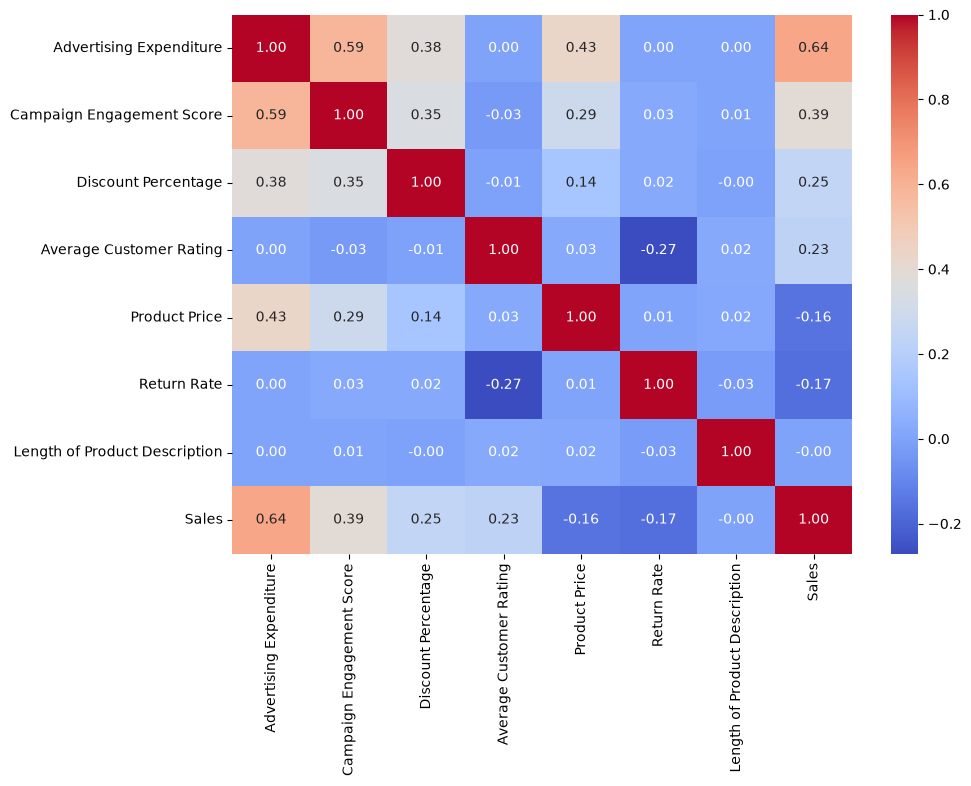

In [20]:
# defining the figure size
plt.figure(figsize=(10, 7))

# plotting the correlation heatmap
sns.heatmap(data.corr(numeric_only = True), annot=True, fmt='0.2f', cmap='coolwarm');

- Sales is indeed highly positively correlated with Advertising Expenditure.
- Sales are indeed negatively correlated with Product Price and Return Rate, but the strength of the correlation is low.
- Advertising Expenditure and Campaign Engagement Score are positively correlated.
- Return Rate and Average Customer Rating are negatively correlated.

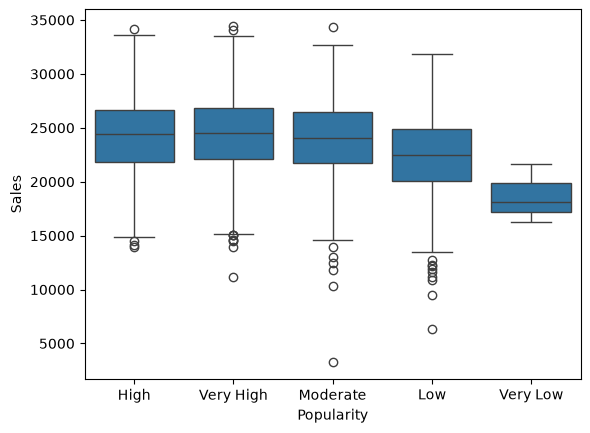

In [21]:
sns.boxplot(data=data, y='Sales', x='Popularity');

* We observe lower sales for unpopular products.

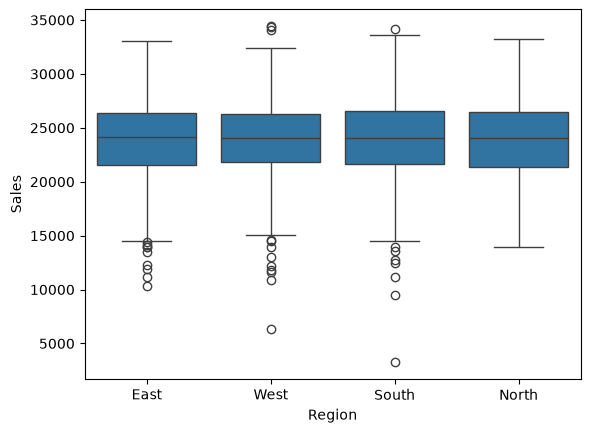

In [22]:
sns.boxplot(data=data, y='Sales', x='Region');

* Sales seem to be uniform across different regions.

# **Data Preparation for Modeling**

In [23]:
# defining the explanatory (independent) and response (dependent) variables
X = data.drop('Sales', axis=1)
y = data['Sales']

In [24]:
# splitting the data in 80:20 ratio for train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,    # specifying the independent variables
    y,    # specifying the dependent variable
    test_size=0.20,    # specifying the size of the test set as a fraction of the whole data
    random_state=42    # specifying a seed value to enable reproducible results
)

##  **Model Building**

## **Simple Linear Regression - `Sales` vs `Advertising Expenditure`**

In [25]:
# defining the independent variable
ind_vars1 = ['Advertising Expenditure']

In [26]:
# creating an instance of the linear regression model
lin_reg1 = LinearRegression()

# fitting the model to the training data
lin_reg1.fit(X_train[ind_vars1], y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[28.67]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Advertising Expenditure']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6436
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [27]:
# printing the linear regression coefficients
print(
    "Slope:", lin_reg1.coef_,
    "Intercept:", lin_reg1.intercept_,
)

Slope: [28.66748755] Intercept: 6435.891302271026


In [28]:
# printing the linear regression equation
print(
    "Sales =",
     "(", lin_reg1.coef_[0], ")", "*", ind_vars1[0],
    "+", lin_reg1.intercept_,
)

Sales = ( 28.667487552010247 ) * Advertising Expenditure + 6435.891302271026


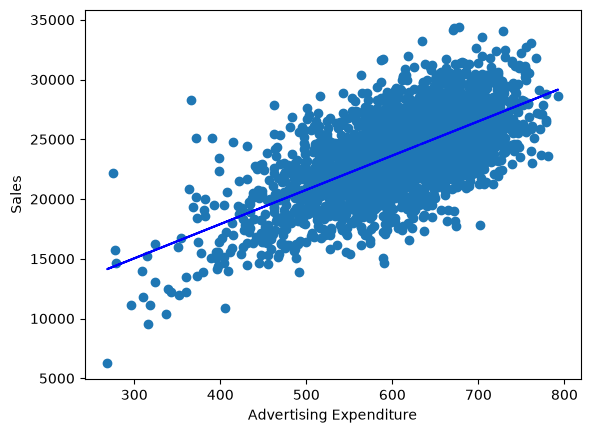

In [29]:
# plotting the best-fit line
fitted_values1 = lin_reg1.predict(X_train[ind_vars1])

# Plot the scatterplot and regression line
plt.scatter(X_train[ind_vars1], y_train)
plt.plot(X_train[ind_vars1], fitted_values1, color='blue')
plt.xlabel(ind_vars1[0])
plt.ylabel('Sales')
plt.show()

## **Simple Linear Regression - `Sales` vs `Discount Percentage`**

In [30]:
# defining the independent variable
ind_vars2 = ['Discount Percentage']

In [31]:
# creating an instance of the linear regression model
lin_reg2 = LinearRegression()

# fitting the model to the training data
lin_reg2.fit(X_train[ind_vars2], y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[188.39]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Discount Percentage']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.841e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [32]:
# printing the linear regression coefficients
print(
    "Slope:", lin_reg2.coef_,
    "Intercept:", lin_reg2.intercept_,
)

Slope: [188.3855554] Intercept: 18411.681879531294


In [33]:
# printing the linear regression equation
print(
    "Sales =",
    "(", lin_reg2.coef_[0], ")", "*", ind_vars2[0],
    "+", lin_reg2.intercept_,
)

Sales = ( 188.3855554032925 ) * Discount Percentage + 18411.681879531294


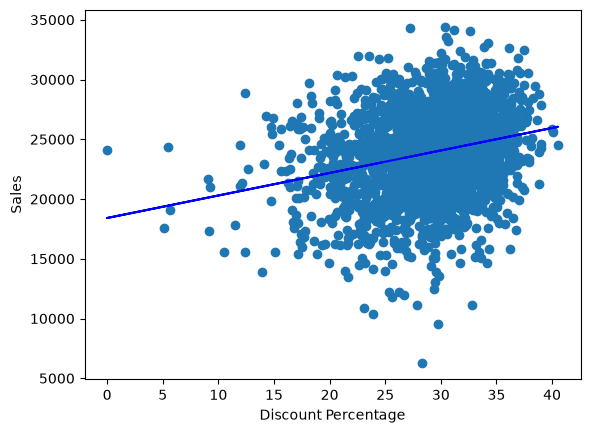

In [34]:
# plotting the best-fit line
fitted_values2 = lin_reg2.predict(X_train[ind_vars2])

# Plot the scatterplot and regression line
plt.scatter(X_train[ind_vars2], y_train)
plt.plot(X_train[ind_vars2], fitted_values2, color='blue')
plt.xlabel(ind_vars2[0])
plt.ylabel('Sales')
plt.show()

## **Simple Linear Regression - `Sales` vs `Product Price`**

In [35]:
# defining the independent variable
ind_vars3 = ['Product Price']

In [36]:
# creating an instance of the linear regression model
lin_reg3 = LinearRegression()

# fitting the model to the training data
lin_reg3.fit(X_train[ind_vars3], y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-2.54]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Product Price']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.752e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [37]:
# printing the linear regression coefficients
print(
    "Slope:", lin_reg3.coef_,
    "Intercept:", lin_reg3.intercept_,
)

Slope: [-2.53923205] Intercept: 27522.91607345547


In [38]:
# printing the linear regression equation
print(
    "Sales =",
    "(", lin_reg3.coef_[0], ")", "*", ind_vars3[0],
    "+", lin_reg3.intercept_,
)

Sales = ( -2.539232052840615 ) * Product Price + 27522.91607345547


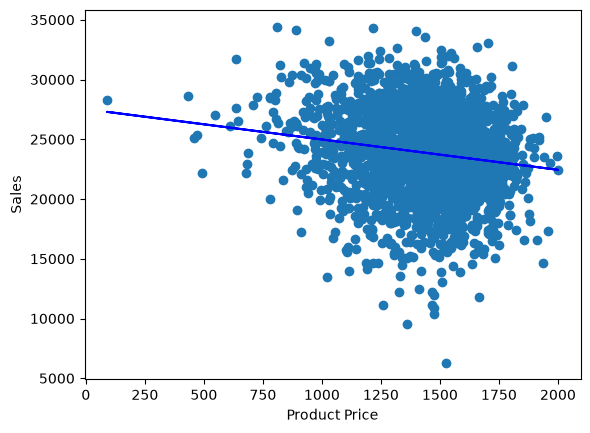

In [39]:
# plotting the best-fit line
fitted_values3 = lin_reg3.predict(X_train[ind_vars3])

# Plot the scatterplot and regression line
plt.scatter(X_train[ind_vars3], y_train)
plt.plot(X_train[ind_vars3], fitted_values3, color='blue')
plt.xlabel(ind_vars3[0])
plt.ylabel('Sales')
plt.show()

## **Multiple Linear Regression - `Sales` vs `Advertising Expenditure`, `Discount Percentage`**

In [40]:
# defining the independent variables
ind_vars4 = ['Advertising Expenditure', 'Discount Percentage']

In [41]:
# creating an instance of the linear regression model
lin_reg4 = LinearRegression()

# fitting the model to the training data
lin_reg4.fit(X_train[ind_vars4], y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[28.71,-1.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Advertising Expenditure','Discount Percentage']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6463
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [42]:
# printing the linear regression coefficients
print(
    "Coefficients:", lin_reg4.coef_, lin_reg4.intercept_
)

Coefficients: [28.70843207 -1.80363464] 6463.321146716928


In [43]:
# printing the linear regression equation
print(
    "Sales =",
    "(", lin_reg4.coef_[0], ")", "*", ind_vars4[0],
    "+ (", lin_reg4.coef_[1], ")", "*", ind_vars4[1],
    "+", lin_reg4.intercept_,
)

Sales = ( 28.70843207445036 ) * Advertising Expenditure + ( -1.8036346364589777 ) * Discount Percentage + 6463.321146716928


## **Multiple Linear Regression - `Sales` vs `Advertising Expenditure`, `Discount Percentage`, `Product Price`**

In [44]:
# defining the independent variables
ind_vars5 = ['Advertising Expenditure', 'Discount Percentage', 'Product Price']

In [45]:
# creating an instance of the linear regression model
lin_reg5 = LinearRegression()

# fitting the model to the training data
lin_reg5.fit(X_train[ind_vars5], y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[38.44,-3.57,-8.46]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Advertising Expenditure','Discount Percentage','Product Price']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.273e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [46]:
# printing the linear regression coefficients
print(
    "Coefficients:", lin_reg5.coef_, lin_reg5.intercept_
)

Coefficients: [38.43656519 -3.57483935 -8.4559953 ] 12731.131575406753


In [47]:
# printing the linear regression equation
print(
    "Sales =",
    "(", lin_reg5.coef_[0], ")", "*", ind_vars5[0],
    "+ (", lin_reg5.coef_[1], ")", "*", ind_vars5[1],
    "+ (", lin_reg5.coef_[2], ")", "*", ind_vars5[2],
    "+", lin_reg5.intercept_,
)

Sales = ( 38.43656519116551 ) * Advertising Expenditure + ( -3.5748393468180044 ) * Discount Percentage + ( -8.455995295705074 ) * Product Price + 12731.131575406753


## **Multiple Linear Regression - `Sales` vs `Advertising Expenditure`, `Discount Percentage`, `Product Price`, `Popularity`**

We first need to label encode the `Popularity` column.

In [48]:
# defining the label encoding
lab_enc = {
    'Very Low': 1,
    'Low': 2,
    'Moderate': 3,
    'High': 4,
    'Very High': 5,
}

In [49]:
 # encoding the Popularity column
X['Popularity'] = X['Popularity'].map(
    lambda x: lab_enc[x]
)

X.head()

,Advertising Expenditure,Campaign Engagement Score,Discount Percentage,Average Customer Rating,Product Price,Return Rate,Length of Product Description,Region,Popularity
0,644.049317,54.565531,25.267151,4.604634,1599.575723,2.133580,231.185389,East,4
1,521.483294,46.875226,35.075859,4.358693,1586.464404,1.553437,262.686931,West,5
2,540.079510,42.287145,12.618381,4.571018,1301.644856,2.274891,324.347319,South,5
3,627.938419,61.825441,31.588445,4.234209,1601.041884,1.035971,447.710984,South,5
4,471.149948,31.061512,9.198991,4.816215,1496.734345,3.276840,310.055333,East,3


In [50]:
# splitting the data in 80:20 ratio for train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,    # specifying the independent variables
    y,    # specifying the dependent variable
    test_size=0.20,    # specifying the size of the test set as a fraction of the whole data
    random_state=42    # specifying a seed value to enable reproducible results
)

In [51]:
# defining the independent variables
ind_vars6 = ['Advertising Expenditure', 'Discount Percentage', 'Product Price', 'Popularity']

In [52]:
# creating an instance of the linear regression model
lin_reg6 = LinearRegression()

# fitting the model to the training data
lin_reg6.fit(X_train[ind_vars6], y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 38.3 , -1.59, -8.52,542.7 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Advertising Expenditure','Discount Percentage','Product Price', 'Popularity']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.076e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [53]:
# printing the linear regression coefficients
print(
    "Coefficients:", lin_reg6.coef_, lin_reg6.intercept_
)

Coefficients: [ 38.29568342  -1.58779804  -8.51597761 542.69784813] 10758.596248519574


In [54]:
# printing the linear regression equation
print(
    "Sales =",
    "(", lin_reg6.coef_[0], ")", "*", ind_vars6[0],
    "+ (", lin_reg6.coef_[1], ")", "*", ind_vars6[1],
    "+ (", lin_reg6.coef_[2], ")", "*", ind_vars6[2],
    "+ (", lin_reg6.coef_[3], ")", "*", ind_vars6[3],
    "+", lin_reg6.intercept_,
)

Sales = ( 38.295683415534135 ) * Advertising Expenditure + ( -1.5877980394796385 ) * Discount Percentage + ( -8.515977612063974 ) * Product Price + ( 542.6978481319414 ) * Popularity + 10758.596248519574


## **Multiple Linear Regression - `Sales` vs All independent variables**

We first need to one-hot encode the `Region` column.

In [55]:
# creating one-hot encoded (also called dummy) variables
X = pd.get_dummies(
    X,    # defining the dataframe from where to fetch the data
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),    # defining the type of columns for which dummies will be made
    drop_first=True,    # dropping the first dummy column
)

# specifying the datatype of the independent variables dataframe
X = X.astype(float)

X.head()

C:\Users\New\AppData\Local\Temp\ipykernel_13732\3041710463.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),    # defining the type of columns for which dummies will be made


,Advertising Expenditure,Campaign Engagement Score,Discount Percentage,Average Customer Rating,Product Price,Return Rate,Length of Product Description,Popularity,Region_North,Region_South,Region_West
0,644.049317,54.565531,25.267151,4.604634,1599.575723,2.133580,231.185389,4.0,0.0,0.0,0.0
1,521.483294,46.875226,35.075859,4.358693,1586.464404,1.553437,262.686931,5.0,0.0,0.0,1.0
2,540.079510,42.287145,12.618381,4.571018,1301.644856,2.274891,324.347319,5.0,0.0,1.0,0.0
3,627.938419,61.825441,31.588445,4.234209,1601.041884,1.035971,447.710984,5.0,0.0,1.0,0.0
4,471.149948,31.061512,9.198991,4.816215,1496.734345,3.276840,310.055333,3.0,0.0,0.0,0.0


* Note that the dummy variable corresponding to the '*East*' category has been dropped.

In [56]:
# splitting the data in 80:20 ratio for train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,    # specifying the independent variables
    y,    # specifying the dependent variable
    test_size=0.20,    # specifying the size of the test set as a fraction of the whole data
    random_state=42    # specifying a seed value to enable reproducible results
)

In [57]:
# creating an instance of the linear regression model
lin_reg7 = LinearRegression()

# fitting the model to the training data
lin_reg7.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 36.8 , 20.78, -6.92,..., -6.98, 52.88,189.17]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['Advertising Expenditure','Campaign Engagement Score', 'Discount Percentage',...,'Region_North','Region_South','Region_West']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,469.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)


In [58]:
# printing the linear regression coefficients
print(
    "Coefficients:", lin_reg7.coef_, lin_reg7.intercept_
)

Coefficients: [ 3.68003768e+01  2.07776337e+01 -6.91846629e+00  2.89027810e+03
 -8.67003378e+00 -4.44787734e+02 -5.08833857e-02  1.46842283e+02
 -6.98114448e+00  5.28817618e+01  1.89167361e+02] 469.59902990095


In [59]:
# printing the linear regression equation
equation = "Sales = ( " + str(lin_reg7.coef_[0]) + " ) * " + X_train.columns.tolist()[0]

for i in range(1, lin_reg7.coef_.shape[0]):
    equation += " + ( " + str(lin_reg7.coef_[i]) + " ) * " + X_train.columns.tolist()[i]

equation +=  " + " + str(lin_reg7.intercept_)

print(equation)

Sales = ( 36.80037684442148 ) * Advertising Expenditure + ( 20.777633698249456 ) * Campaign Engagement Score + ( -6.918466291296808 ) * Discount Percentage + ( 2890.2781015158216 ) * Average Customer Rating + ( -8.670033784471652 ) * Product Price + ( -444.7877341802198 ) * Return Rate + ( -0.050883385681236196 ) * Length of Product Description + ( 146.84228310853246 ) * Popularity + ( -6.981144476906765 ) * Region_North + ( 52.88176184796152 ) * Region_South + ( 189.16736137257132 ) * Region_West + 469.59902990095


# **Model Performance Evaluation**

We first define a set of utility functions to compute MAPE and Adjusted $R^2$, and another one to collate all the metrics into a single dataframe.

In [60]:
# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100

# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regression model
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE
    r2 = r2_score(target, pred)  # to compute R-squared
    adj_r2 = adj_r2_score(predictors, target, pred)  # to compute Adjusted R-squared

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "MAPE": mape,
            "R-squared": r2,
            "Adj R-squared": adj_r2,
        },
        index=[0],
    )

    return df_perf

We'll now check the performance of all the models we've built so far.



## **Simple Linear Regression - `Sales` vs `Advertising Expenditure`**

In [61]:
lin_reg1_train_perf = model_performance_regression(lin_reg1, X_train[ind_vars1], y_train)
lin_reg1_train_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,2753.419094,2207.551603,9.647262,0.415783,0.415539


In [62]:
lin_reg1_test_perf = model_performance_regression(lin_reg1, X_test[ind_vars1], y_test)
lin_reg1_test_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,2857.307226,2226.476254,9.96158,0.385518,0.38449


## **Simple Linear Regression - `Sales` vs `Discount Percentage`**

In [63]:
lin_reg2_train_perf = model_performance_regression(lin_reg2, X_train[ind_vars2], y_train)
lin_reg2_train_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,3489.766337,2761.85512,12.464781,0.061525,0.061134


In [64]:
lin_reg2_test_perf = model_performance_regression(lin_reg2, X_test[ind_vars2], y_test)
lin_reg2_test_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,3524.541373,2797.50262,13.334384,0.065023,0.06346


## **Simple Linear Regression - `Sales` vs `Product Price`**

In [65]:
lin_reg3_train_perf = model_performance_regression(lin_reg3, X_train[ind_vars3], y_train)
lin_reg3_train_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,3558.436048,2816.479842,12.759044,0.024228,0.023821


In [66]:
lin_reg3_test_perf = model_performance_regression(lin_reg3, X_test[ind_vars3], y_test)
lin_reg3_test_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,3601.594159,2843.696093,13.700047,0.023696,0.022063


## **Multiple Linear Regression - `Sales` vs `Advertising Expenditure`, `Discount Percentage`**

In [67]:
lin_reg4_train_perf = model_performance_regression(lin_reg4, X_train[ind_vars4], y_train)
lin_reg4_train_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,2753.407802,2207.640909,9.64753,0.415787,0.4153


In [68]:
lin_reg4_test_perf = model_performance_regression(lin_reg4, X_test[ind_vars4], y_test)
lin_reg4_test_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,2857.608291,2226.948004,9.96336,0.385388,0.383329


## **Multiple Linear Regression - `Sales` vs `Advertising Expenditure`, `Discount Percentage`, `Product Price`**

In [69]:
lin_reg5_train_perf = model_performance_regression(lin_reg5, X_train[ind_vars5], y_train)
lin_reg5_train_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,2170.436447,1757.487072,7.641589,0.636985,0.636531


In [70]:
lin_reg5_test_perf = model_performance_regression(lin_reg5, X_test[ind_vars5], y_test)
lin_reg5_test_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,2179.437285,1740.589014,7.657319,0.642493,0.640694


## **Multiple Linear Regression - `Sales` vs `Advertising Expenditure`, `Discount Percentage`, `Product Price`, `Popularity`**

In [71]:
lin_reg6_train_perf = model_performance_regression(lin_reg6, X_train[ind_vars6], y_train)
lin_reg6_train_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,2079.919471,1680.33272,7.286114,0.666633,0.666076


In [72]:
lin_reg6_test_perf = model_performance_regression(lin_reg6, X_test[ind_vars6], y_test)
lin_reg6_test_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,2047.484172,1639.883732,7.15333,0.684473,0.682352


## **Multiple Linear Regression - `Sales` vs All independent variables**

In [73]:
lin_reg7_train_perf = model_performance_regression(lin_reg7, X_train, y_train)
lin_reg7_train_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,1940.930335,1564.829605,6.785088,0.709698,0.708361


In [74]:
lin_reg7_test_perf = model_performance_regression(lin_reg7, X_test, y_test)
lin_reg7_test_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,1907.839718,1558.392467,6.763019,0.726045,0.72092


# **Model Performance Comparison**

In [75]:
# training performance comparison

# concatenating all the training performance dataframes
models_train_comp_df = pd.concat(
    [
        lin_reg1_train_perf.T,
        lin_reg2_train_perf.T,
        lin_reg3_train_perf.T,
        lin_reg4_train_perf.T,
        lin_reg5_train_perf.T,
        lin_reg6_train_perf.T,
        lin_reg7_train_perf.T,
    ],
    axis=1,
)

# defining the list of models built
models_train_comp_df.columns = [
    "Simple Linear Regression - Sales vs Advertising Expenditure",
    "Simple Linear Regression - Sales vs Discount Percentage",
    "Simple Linear Regression - Sales vs Product Price",
    "Multiple Linear Regression - Sales vs Advertising Expenditure, Discount Percentage",
    "Multiple Linear Regression - Sales vs Advertising Expenditure, Discount Percentage, Product Price",
    "Multiple Linear Regression - Sales vs Advertising Expenditure, Discount Percentage, Product Price, Popularity",
    "Multiple Linear Regression - Sales vs All independent variables",
]

print("Training performance comparison:")
models_train_comp_df.T

Training performance comparison:


,RMSE,MAE,MAPE,R-squared,Adj R-squared
Simple Linear Regression - Sales vs Advertising Expenditure,2753.419094,2207.551603,9.647262,0.415783,0.415539
Simple Linear Regression - Sales vs Discount Percentage,3489.766337,2761.855120,12.464781,0.061525,0.061134
Simple Linear Regression - Sales vs Product Price,3558.436048,2816.479842,12.759044,0.024228,0.023821
"Multiple Linear Regression - Sales vs Advertising Expenditure, Discount Percentage",2753.407802,2207.640909,9.647530,0.415787,0.415300
"Multiple Linear Regression - Sales vs Advertising Expenditure, Discount Percentage, Product Price",2170.436447,1757.487072,7.641589,0.636985,0.636531
"Multiple Linear Regression - Sales vs Advertising Expenditure, Discount Percentage, Product Price, Popularity",2079.919471,1680.332720,7.286114,0.666633,0.666076
Multiple Linear Regression - Sales vs All independent variables,1940.930335,1564.829605,6.785088,0.709698,0.708361


In [76]:
# test performance comparison

# concatenating all the test performance dataframes
models_test_comp_df = pd.concat(
    [
        lin_reg1_test_perf.T,
        lin_reg2_test_perf.T,
        lin_reg3_test_perf.T,
        lin_reg4_test_perf.T,
        lin_reg5_test_perf.T,
        lin_reg6_test_perf.T,
        lin_reg7_test_perf.T,
    ],
    axis=1,
)

# defining the list of models built
models_test_comp_df.columns = [
    "Simple Linear Regression - Sales vs Advertising Expenditure",
    "Simple Linear Regression - Sales vs Discount Percentage",
    "Simple Linear Regression - Sales vs Product Price",
    "Multiple Linear Regression - Sales vs Advertising Expenditure, Discount Percentage",
    "Multiple Linear Regression - Sales vs Advertising Expenditure, Discount Percentage, Product Price",
    "Multiple Linear Regression - Sales vs Advertising Expenditure, Discount Percentage, Product Price, Popularity",
    "Multiple Linear Regression - Sales vs All independent variables",
]

print("Test performance comparison:")
models_test_comp_df.T

Test performance comparison:


,RMSE,MAE,MAPE,R-squared,Adj R-squared
Simple Linear Regression - Sales vs Advertising Expenditure,2857.307226,2226.476254,9.961580,0.385518,0.384490
Simple Linear Regression - Sales vs Discount Percentage,3524.541373,2797.502620,13.334384,0.065023,0.063460
Simple Linear Regression - Sales vs Product Price,3601.594159,2843.696093,13.700047,0.023696,0.022063
"Multiple Linear Regression - Sales vs Advertising Expenditure, Discount Percentage",2857.608291,2226.948004,9.963360,0.385388,0.383329
"Multiple Linear Regression - Sales vs Advertising Expenditure, Discount Percentage, Product Price",2179.437285,1740.589014,7.657319,0.642493,0.640694
"Multiple Linear Regression - Sales vs Advertising Expenditure, Discount Percentage, Product Price, Popularity",2047.484172,1639.883732,7.153330,0.684473,0.682352
Multiple Linear Regression - Sales vs All independent variables,1907.839718,1558.392467,6.763019,0.726045,0.720920


* Advertising Expenditure seems to be a good predictor of Sales.
* Discount Percentage and Product Price are individually poor predictors of Sales. But when combined with Advertising Expenditure, they together provide good predictive power.
* The final model with all independent variables exhibits the best performance.